# Data description


- Survived: 0 = Did not survive, 1 = Survived

- Pclass: Ticket class where 1 = First class, 2 = Second class, 3 = Third class. This can also be seen as a proxy for socio-economic status.

- Sex: Male or female

- Age: Age in years, fractional if less than 1

- SibSp: Number of siblings or spouses aboard the titanic

- Parch: Number of parents or children aboard the titanic

- Ticket: Passenger ticket number

- Fare: Passenger fare

- Cabin: Cabin number

- Embarked: Point of embarkation where C = Cherbourg, Q = Queenstown, S = Southampton

Survival probability is highest for location C and lowest for location S.

Is there a reason for this occurence? We can formulate a hypothesis whereby the majority of the first class passengers have embarked from location C and because they have a highest survival probability, this has resulted in location C having a highest survival probability. Alternatively, there could have been more third class passengers that embarked from location S and because they have the lowest survival probability, this has caused location S to have the lowest survival probability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import missingno
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from collections import Counter
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import numpy as np
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, accuracy_score,f1_score, precision_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier  
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score


import warnings

# To ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("titanic_train.csv")
test = pd.read_csv("titanic_test.csv")

print("Training set shape: ", train.shape)
print("Test set shape: ", test.shape)

display(train.head())

Training set shape:  (891, 12)
Test set shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis (EDA)

In [3]:
print("=" * 50)
print("TRAINING DATA")
print("=" * 50)
train.info()

print("\nMissing Values (Training Data)")
print(train.isnull().sum().sort_values(ascending=False))

print("\n" + "=" * 50)
print("TEST DATA")
print("=" * 50)
test.info()

print("\nMissing Values (Test Data)")
print(test.isnull().sum().sort_values(ascending=False))

TRAINING DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values (Training Data)
Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket  

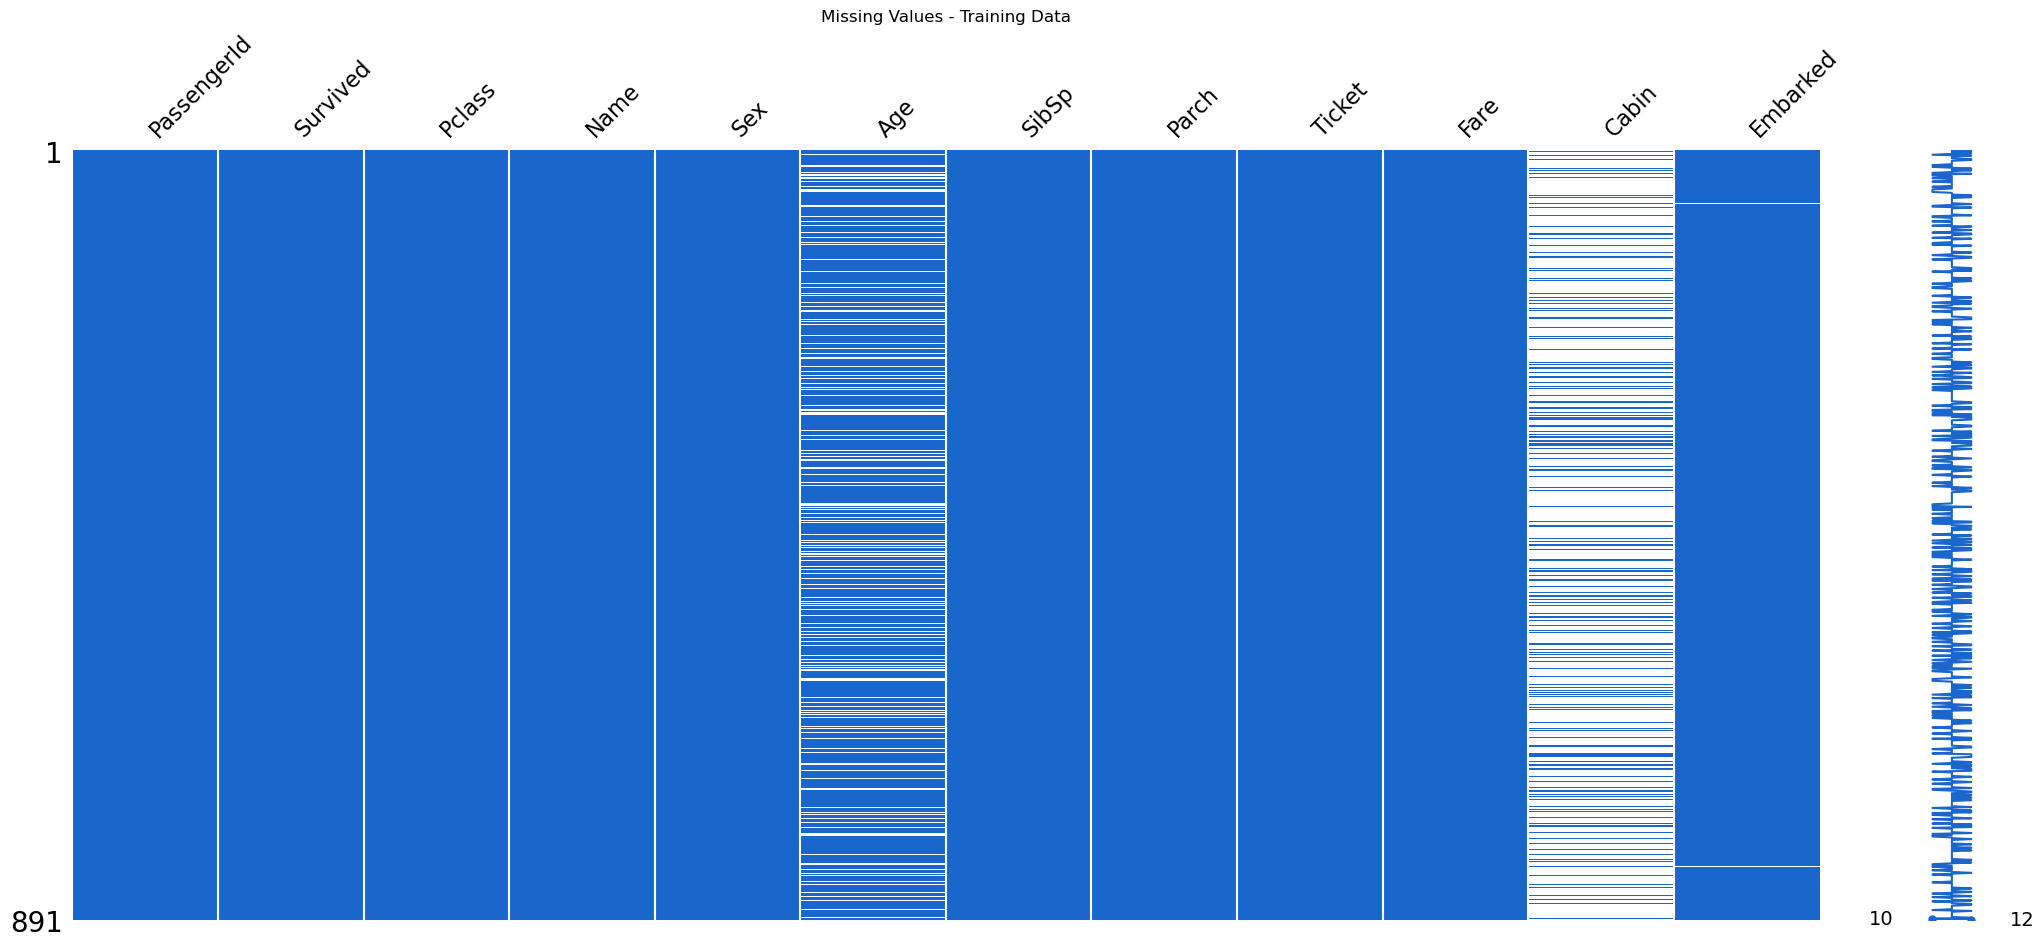

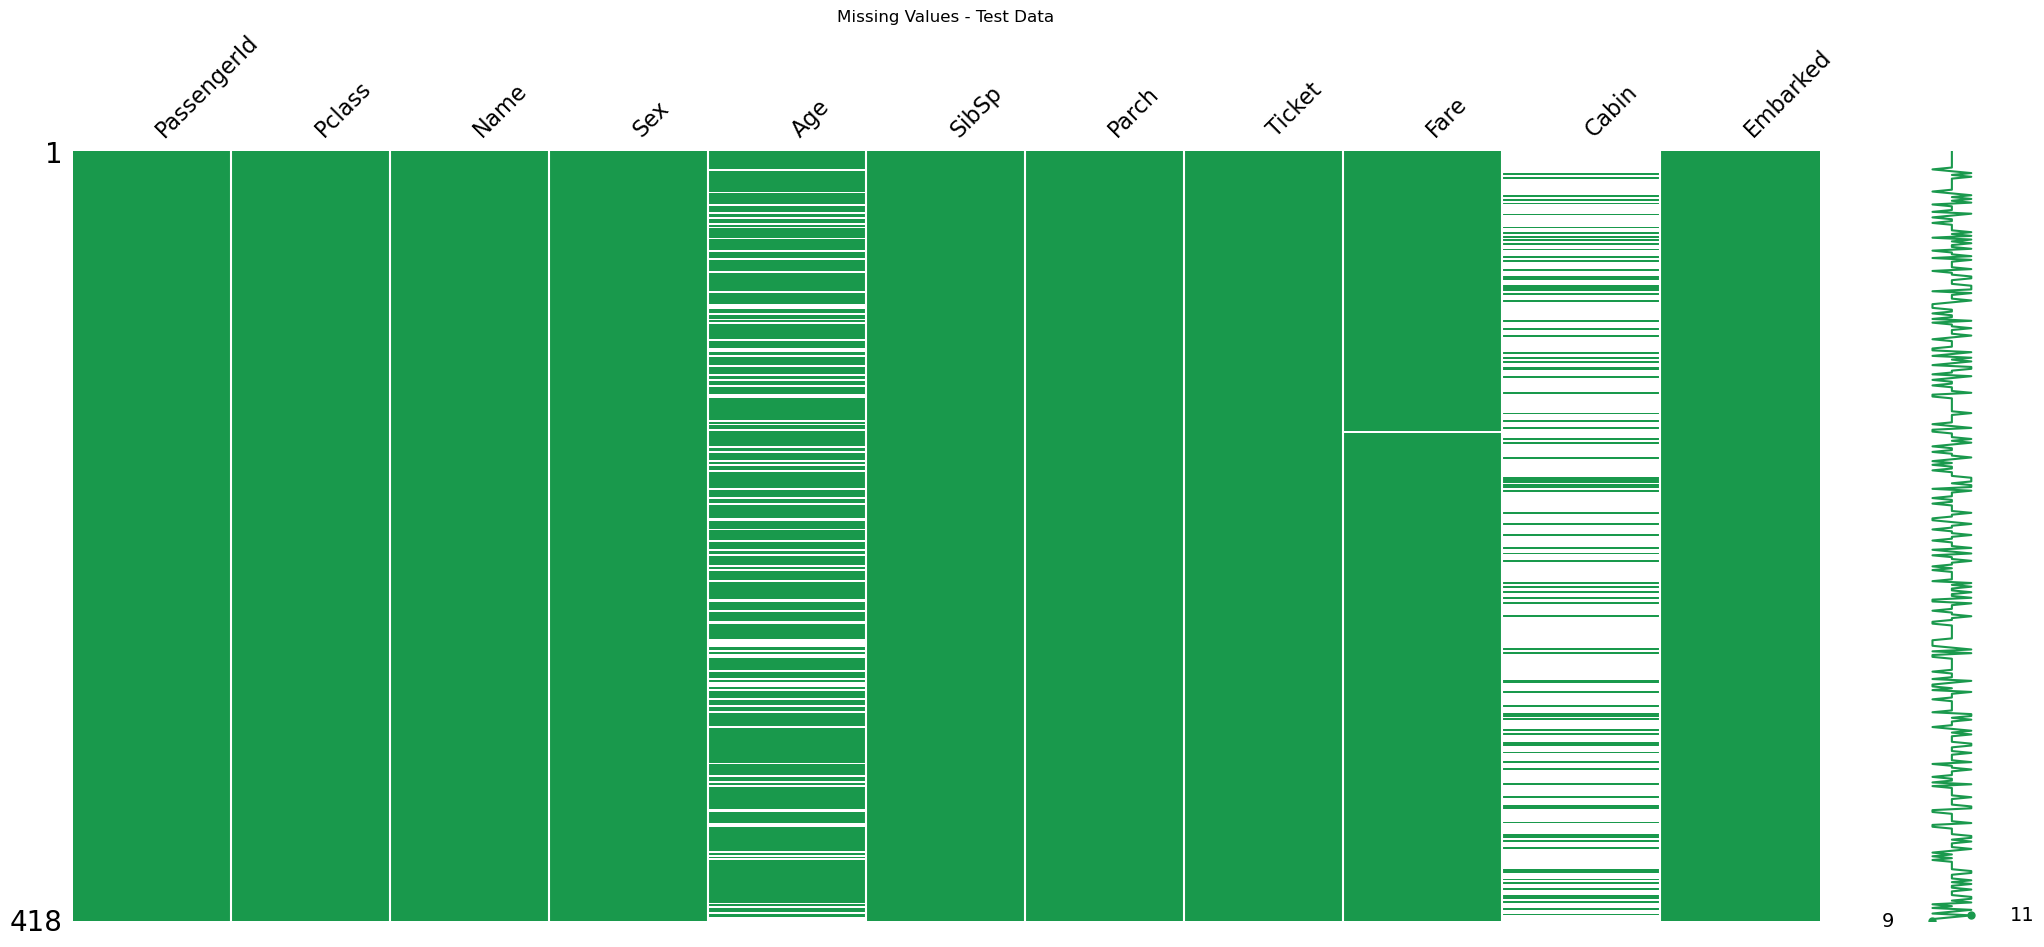

In [4]:
# Missing value matrix - Training Data
missingno.matrix(train, color=(0.1, 0.4, 0.8))
plt.title("Missing Values - Training Data")
plt.show()

# Missing value matrix - Test Data
missingno.matrix(test, color=(0.1, 0.6, 0.3))
plt.title("Missing Values - Test Data")
plt.show()

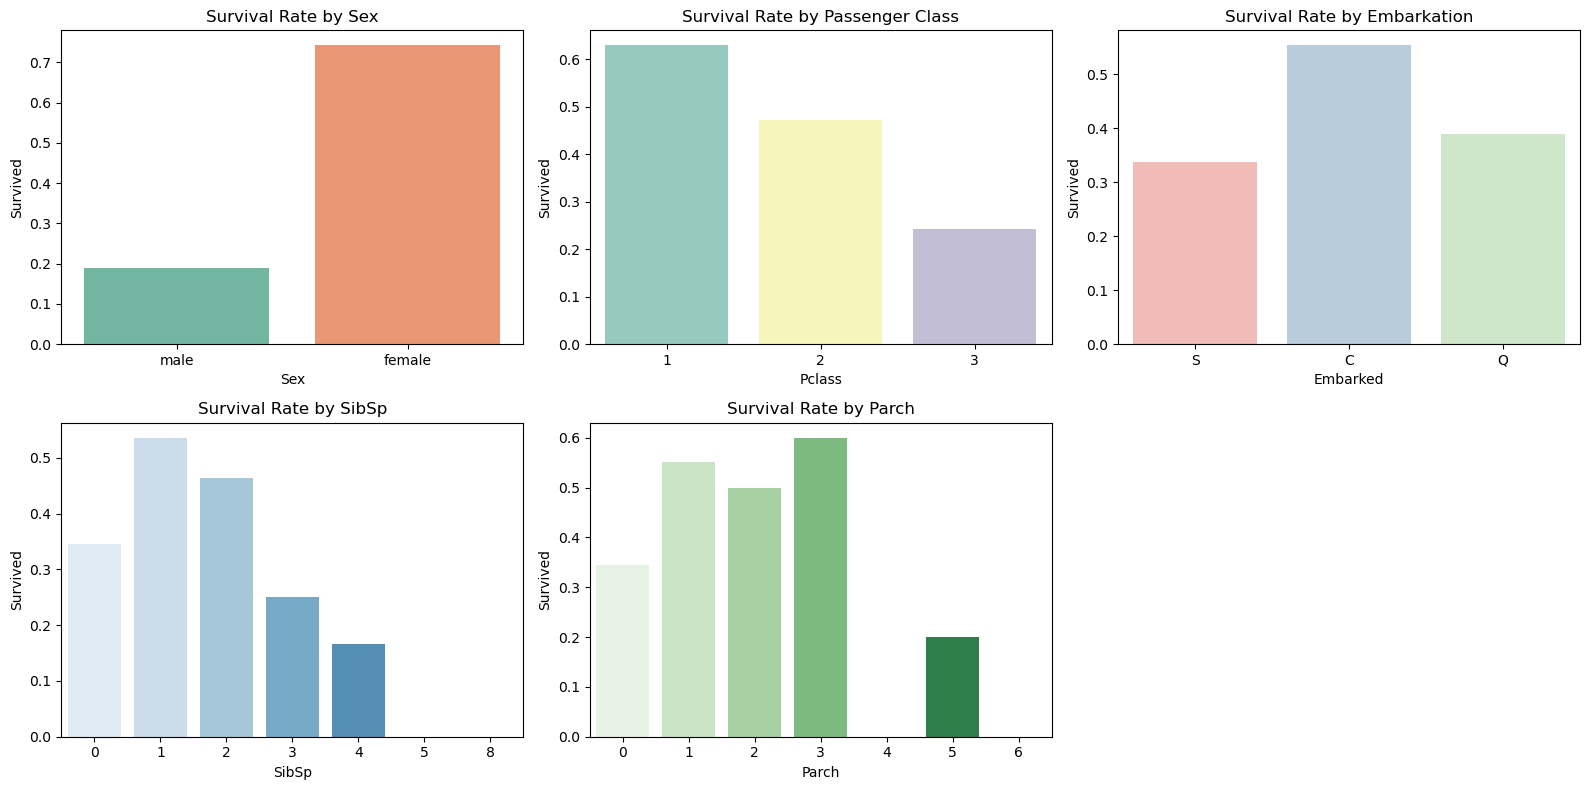

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.barplot(x='Sex', y='Survived', data=train, palette='Set2', errorbar=None, ax=axes[0,0])
axes[0,0].set_title('Survival Rate by Sex')

sns.barplot(x='Pclass', y='Survived', data=train, palette='Set3', errorbar=None, ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Passenger Class')

sns.barplot(x='Embarked', y='Survived', data=train, palette='Pastel1', errorbar=None, ax=axes[0,2])
axes[0,2].set_title('Survival Rate by Embarkation')

sns.barplot(x='SibSp', y='Survived', data=train, palette='Blues', errorbar=None, ax=axes[1,0])
axes[1,0].set_title('Survival Rate by SibSp')

sns.barplot(x='Parch', y='Survived', data=train, palette='Greens', errorbar=None, ax=axes[1,1])
axes[1,1].set_title('Survival Rate by Parch')

fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

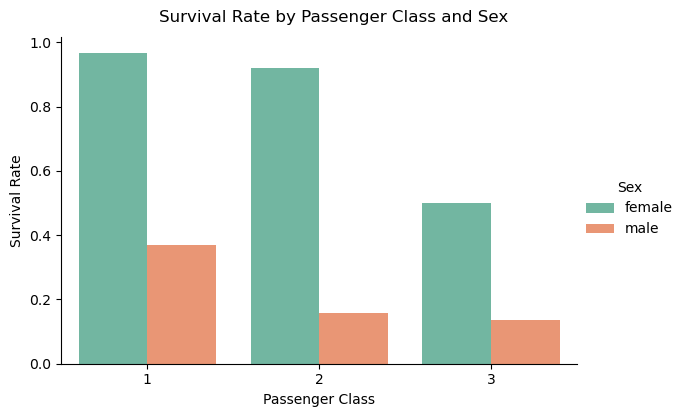

In [6]:
g = sns.catplot(
    x='Pclass',
    y='Survived',
    hue='Sex',
    data=train,
    kind='bar',
    palette='Set2',
    errorbar=None,
    height=4,
    aspect=1.5
)

g.set_axis_labels('Passenger Class', 'Survival Rate')
g.fig.suptitle('Survival Rate by Passenger Class and Sex', y=1.03)
g._legend.set_title('Sex')

Text(0.5, 1.05, 'Passenger Class Distribution by Port of Embarkation')

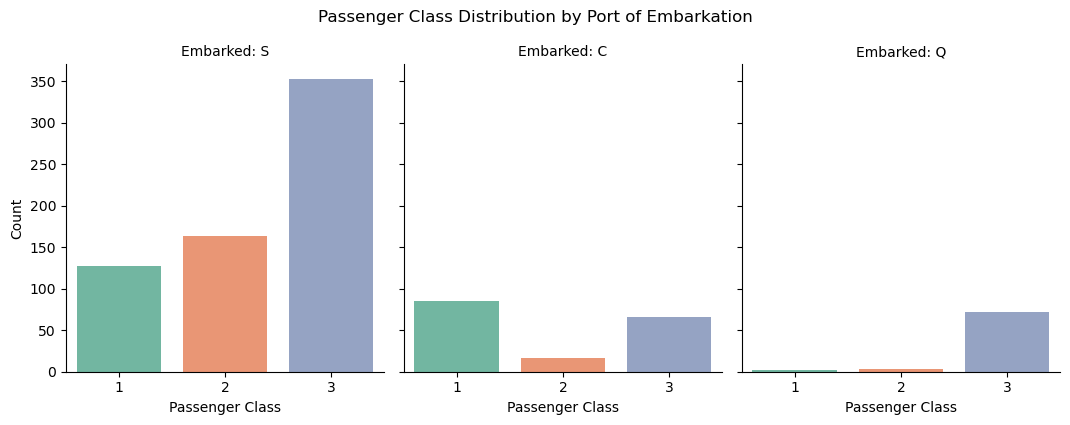

In [7]:
g = sns.catplot(
    x='Pclass',
    col='Embarked',
    data=train,
    kind='count',
    palette='Set2',
    height=4,
    aspect=0.9
)

g.set_axis_labels('Passenger Class', 'Count')
g.set_titles('Embarked: {col_name}')
g.fig.suptitle('Passenger Class Distribution by Port of Embarkation', y=1.05)

Text(0.5, 1.05, 'Survival by Passenger Class and Embarkation Port')

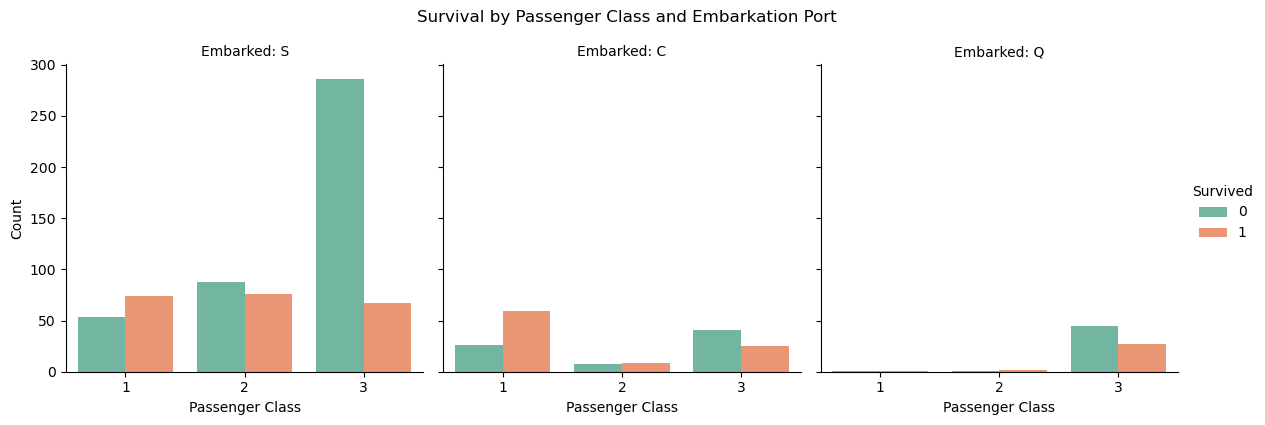

In [8]:
g = sns.catplot(
    x='Pclass',
    hue='Survived',
    col='Embarked',
    data=train,
    kind='count',
    palette='Set2',
    height=4,
    aspect=1
)

g.set_axis_labels('Passenger Class', 'Count')
g.set_titles('Embarked: {col_name}')
g.fig.suptitle('Survival by Passenger Class and Embarkation Port', y=1.05)

## Numerical variables

Numerical variables in our dataset are SibSp, Parch, Age and Fare.

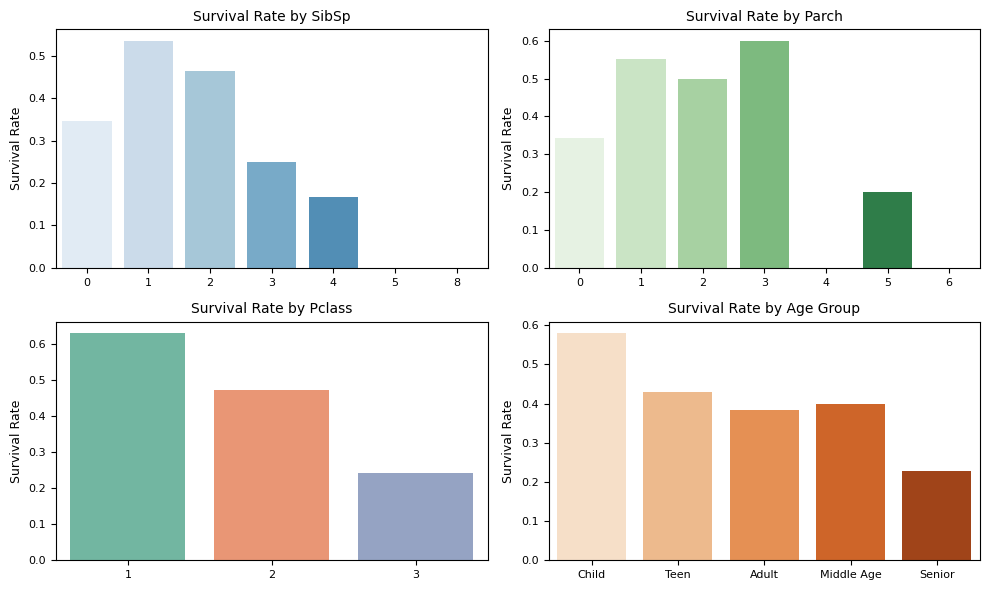

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

sns.barplot(x='SibSp', y='Survived', data=train,
            palette='Blues', errorbar=None, ax=axes[0,0])
axes[0,0].set_title('Survival Rate by SibSp', fontsize=10)

sns.barplot(x='Parch', y='Survived', data=train,
            palette='Greens', errorbar=None, ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Parch', fontsize=10)

sns.barplot(x='Pclass', y='Survived', data=train,
            palette='Set2', errorbar=None, ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Pclass', fontsize=10)

train['AgeGroup'] = pd.cut(train['Age'],
                           bins=[0,12,18,35,60,80],
                           labels=['Child','Teen','Adult','Middle Age','Senior'])

sns.barplot(x='AgeGroup', y='Survived', data=train,
            palette='Oranges', errorbar=None, ax=axes[1,1])
axes[1,1].set_title('Survival Rate by Age Group', fontsize=10)

for ax in axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('Survival Rate', fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

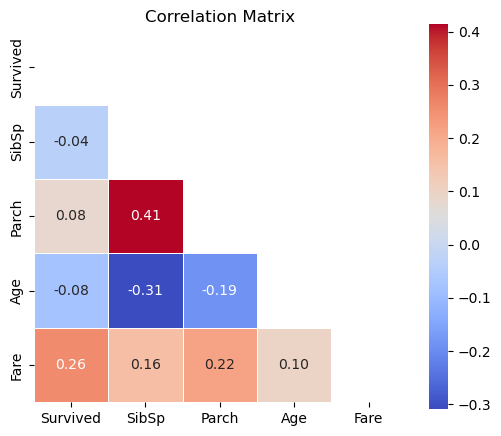

In [10]:
plt.figure(figsize=(6, 5))

mask = np.triu(np.ones_like(train[['Survived', 'SibSp', 'Parch', 'Age', 'Fare']].corr(), dtype=bool))

sns.heatmap(
    train[['Survived', 'SibSp', 'Parch', 'Age', 'Fare']].corr(),
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

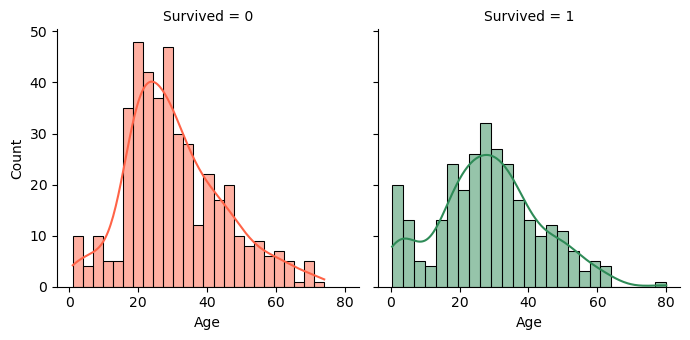

In [11]:
# Age distribution comparison between survived and non-survived passengers

# Create separate plots for each survival category
g = sns.FacetGrid(
    train,
    col='Survived',                  # Create one plot for Survived=0 and one for Survived=1
    hue='Survived',                  # Apply colors based on survival status
    palette=['tomato', 'seagreen'],  # Red for non-survivors, green for survivors
    height=3.5
)

# Plot age distribution with histogram and KDE curve
g.map_dataframe(
    sns.histplot,
    x='Age',
    bins=25,
    kde=True
)

# Set titles and axis labels
g.set_titles('Survived = {col_name}')
g.set_axis_labels('Age', 'Count')

plt.tight_layout()
plt.show()

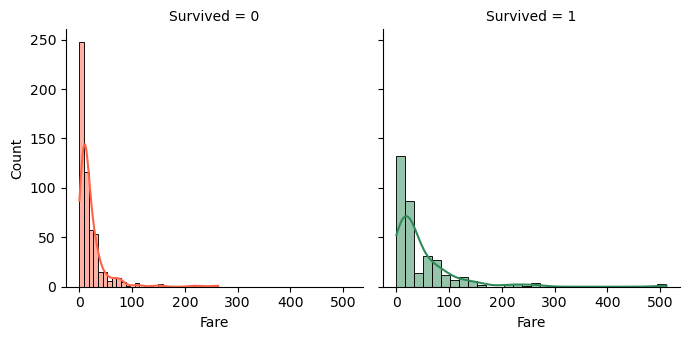

In [12]:
# Fare distribution comparison between survived and non-survived passengers
# Shows whether passengers who paid higher fares had a different survival pattern

g = sns.FacetGrid(
    train,
    col='Survived',                  # Creates separate plots for survived and non-survived passengers
    hue='Survived',                  # Colors the distributions based on survival status
    palette=['tomato', 'seagreen'],  # Red = Did not survive, Green = Survived
    height=3.5
)

# Plot Fare distribution with histogram and KDE curve
# Helps identify whether survival was associated with higher or lower ticket fares
g.map_dataframe(
    sns.histplot,
    x='Fare',
    bins=30,
    kde=True
)

# Set plot titles and labels
g.set_titles('Survived = {col_name}')
g.set_axis_labels('Fare', 'Count')

plt.tight_layout()
plt.show()

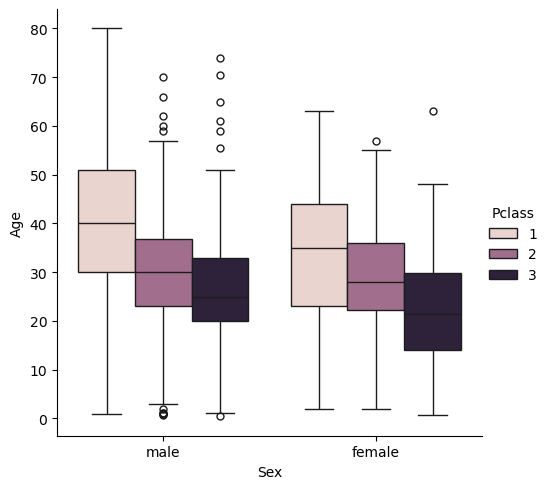

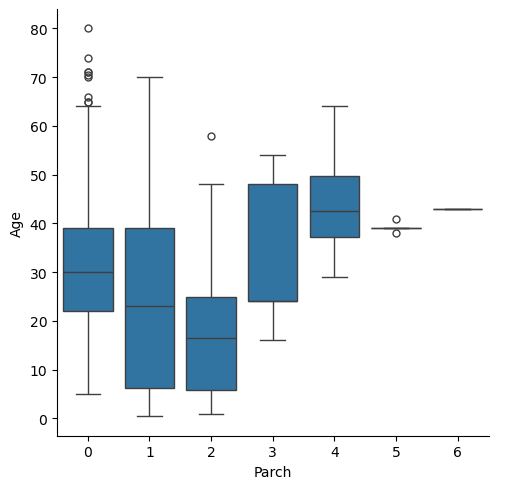

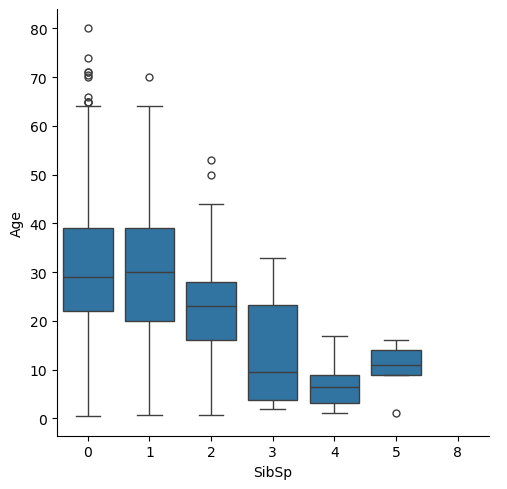

In [13]:
sns.catplot(y = 'Age', x = 'Sex', hue = 'Pclass', kind = 'box', data = train)
sns.catplot(y = 'Age', x = 'Parch', kind = 'box', data = train)
sns.catplot(y = 'Age', x = 'SibSp', kind = 'box', data = train)

In [14]:
print('Train shape:', train.shape)

print('Test shape:', test.shape)

Train shape: (891, 13)
Test shape: (418, 11)


In [15]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Middle Age
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult


In [16]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [17]:
train = train.drop(['PassengerId','Name','AgeGroup','Ticket','Cabin'], axis=1)
test = test.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

# Check missing values before handling
print("Missing values before imputation (Train):")
print(train.isnull().sum().sort_values(ascending=False))

print("\nMissing values before imputation (Test):")
print(test.isnull().sum().sort_values(ascending=False))

Missing values before imputation (Train):
Age         177
Embarked      2
Survived      0
Pclass        0
Sex           0
SibSp         0
Parch         0
Fare          0
dtype: int64

Missing values before imputation (Test):
Age         86
Fare         1
Pclass       0
Sex          0
SibSp        0
Parch        0
Embarked     0
dtype: int64


In [18]:
test.shape

(418, 7)

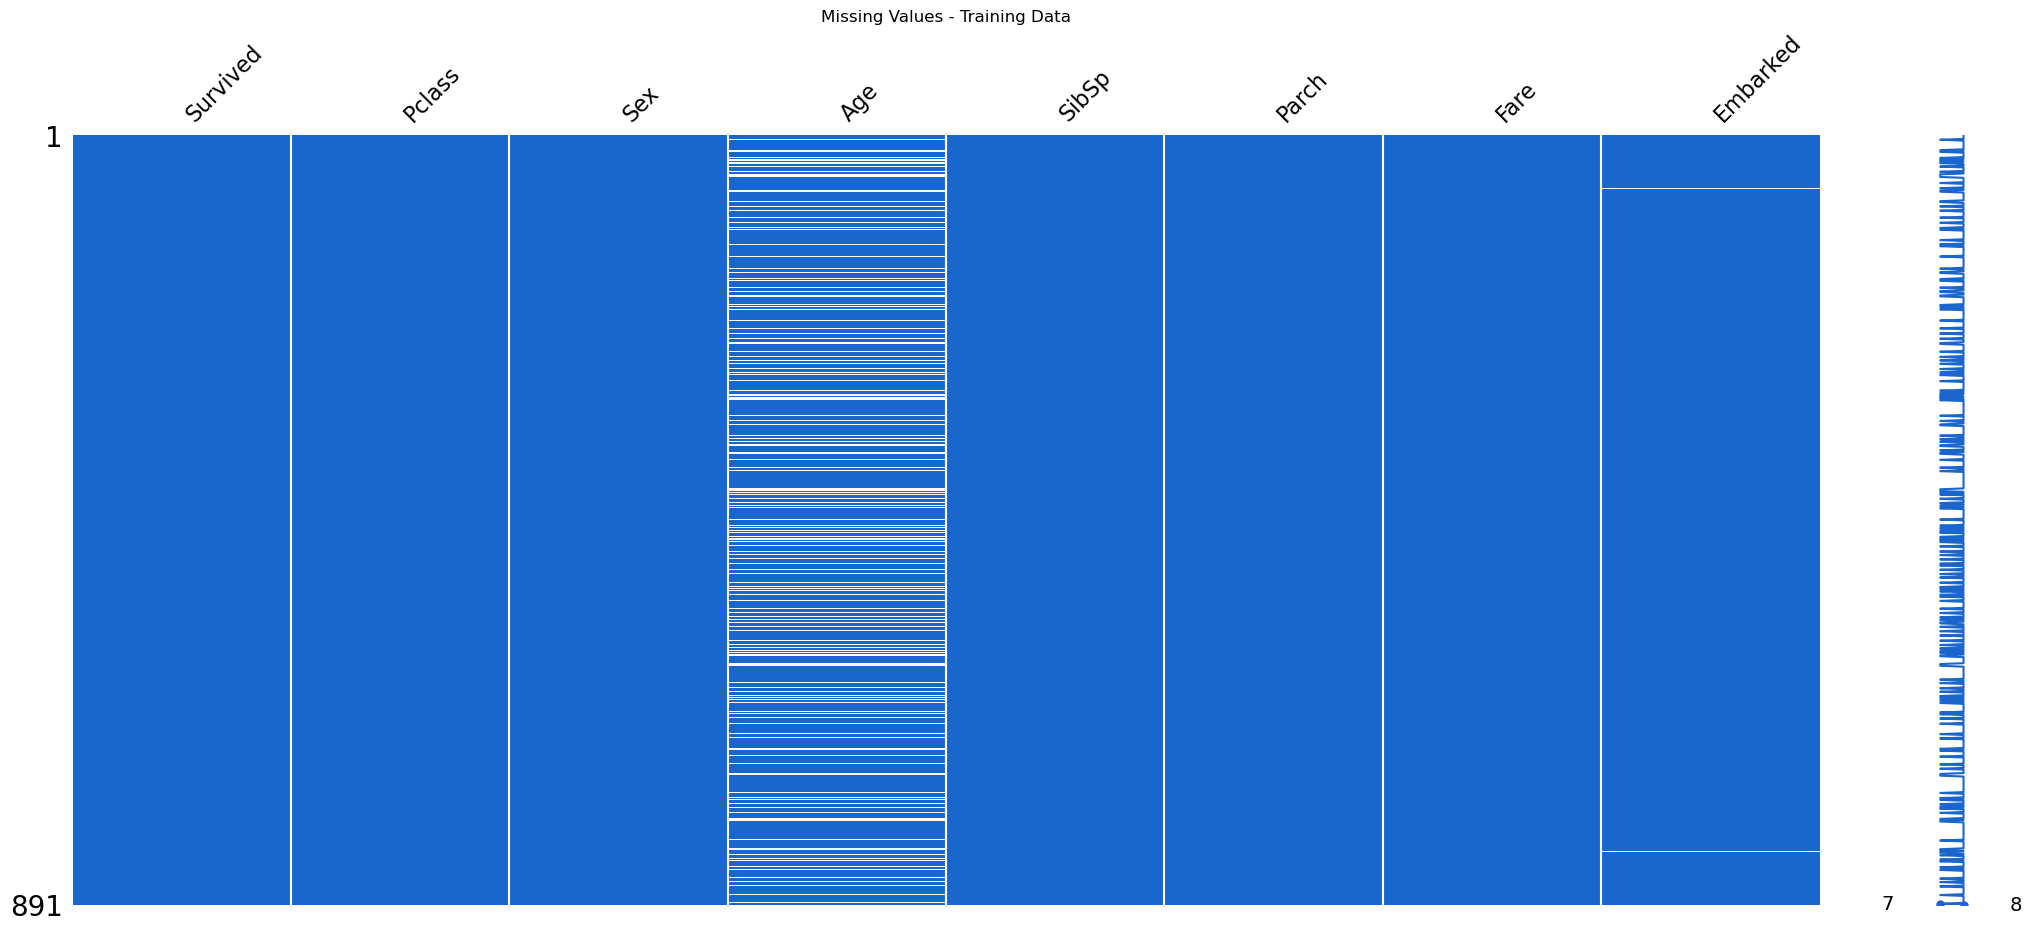

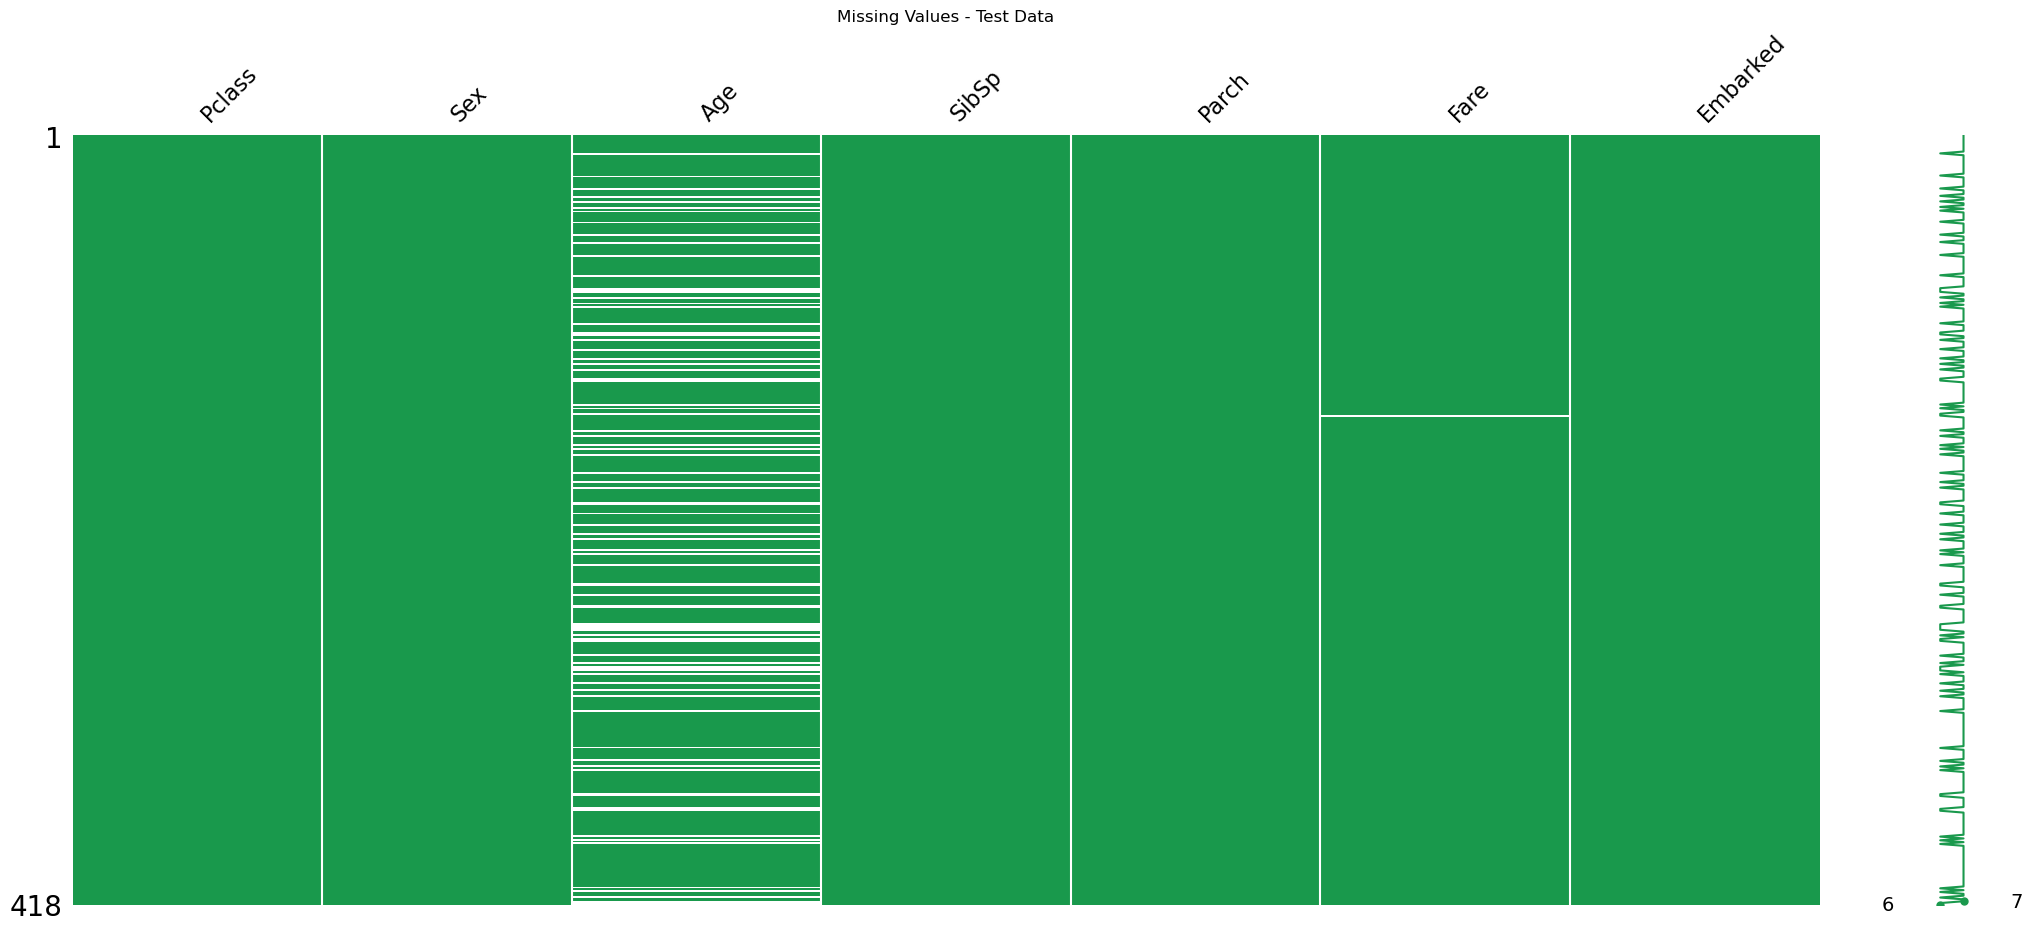

In [19]:
# Missing value matrix - Training Data
missingno.matrix(train, color=(0.1, 0.4, 0.8))
plt.title("Missing Values - Training Data")
plt.show()

# Missing value matrix - Test Data
missingno.matrix(test, color=(0.1, 0.6, 0.3))
plt.title("Missing Values - Test Data")
plt.show()

In [20]:
#Define X and y
x_train = train.drop('Survived', axis=1)
y_train = train['Survived']




#Data Split
x_train, x_test, y_train, y_test = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)


In [21]:
# 1. Separate numerical and categorical columns
num_cols_to_be_imputed = ['Age']
cat_cols_to_be_imputed = ['Embarked','Sex']


In [22]:
num_imputer = SimpleImputer(strategy='median')


cat_imputer = SimpleImputer(strategy='most_frequent')


preprocessor = ColumnTransformer([
    ("Scale", MinMaxScaler(), num_cols),
    ("One Hot Encoding", OneHotEncoder(drop='first',handle_unknown="infrequent_if_exist", min_frequency=4), cat_cols_needing_OHE)
    ],
    remainder='passthrough' )
preprocessor

In [23]:
# Imputation Only

preprocessor_Imputation_Only = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols_to_be_imputed),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',
                                       unknown_value=-1))
        ]), cat_cols_to_be_imputed)
    ],
    remainder='passthrough'
)


In [24]:
criterions = ["gini","entropy"]

results_dt = {
    "Criterion": [],
    "Train Accuracy": [],
    "Test Accuracy": [],
    "Train Precision": [],
    "Test Precision": [],
    "Train Recall": [],
    "Test Recall": [],
    "Train F1": [],
    "Test F1": []
}

for criterion in criterions:

    dt_model = Pipeline([

        # Step 1: Imputation
        ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),

        # Step 2: SMOTE
        ("smote", SMOTE(random_state=42)),

        # Step 3: Decision Tree
        ("classifier", DecisionTreeClassifier(
            criterion=criterion,
            random_state=42
        ))
    ])

    dt_model.fit(x_train, y_train)

    y_train_pred = dt_model.predict(x_train)
    y_test_pred = dt_model.predict(x_test)

    results_dt["Criterion"].append(criterion)
    results_dt["Train Accuracy"].append(accuracy_score(y_train, y_train_pred))
    results_dt["Test Accuracy"].append(accuracy_score(y_test, y_test_pred))
    results_dt["Train Precision"].append(precision_score(y_train, y_train_pred))
    results_dt["Test Precision"].append(precision_score(y_test, y_test_pred))
    results_dt["Train Recall"].append(recall_score(y_train, y_train_pred))
    results_dt["Test Recall"].append(recall_score(y_test, y_test_pred))
    results_dt["Train F1"].append(f1_score(y_train, y_train_pred))
    results_dt["Test F1"].append(f1_score(y_test, y_test_pred))

In [25]:
results_dt = pd.DataFrame(results_dt)

display(results_dt)

,Criterion,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,gini,0.983146,0.804469,0.996198,0.736111,0.959707,0.768116,0.977612,0.751773
1,entropy,0.983146,0.787709,0.996198,0.712329,0.959707,0.753623,0.977612,0.732394


# SVM Model -- Comparing All Kernels (Pipeline)

In [26]:
# Numerical and Categorical Columns
num_cols = ["Age", "Fare", "SibSp", "Parch"]

bi_cat_cols_needing_oe = ["Sex"]

cat_cols_needing_OHE = ["Pclass", "Embarked"]

In [27]:
# Preprocessing -- Imputation + Scaling + Encoding

preprocessor_svm = ColumnTransformer(
    transformers=[

        # Numerical : Median Imputation + Scaling
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        # Sex : Mode Imputation + Ordinal Encoding
        ("sex", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=-1))
        ]), bi_cat_cols_needing_oe),

        # Pclass & Embarked : Mode Imputation + One Hot Encoding
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop='first',handle_unknown="infrequent_if_exist", min_frequency=4))
        ]), cat_cols_needing_OHE)
    ],
    remainder='passthrough'
)

preprocessor_svm

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'SibSp', 'Parch']),
                                ('sex',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Sex']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='infrequent_if_exist',
                                                                min_frequency=4))]),
                                 ['Pclass', 'Embarked'])])

In [28]:
# Compare Different Kernels

kernels = ["linear", "rbf", "poly", "sigmoid"]

results_svm = {
    "Kernel": [],
    "Train Accuracy": [],
    "Test Accuracy": [],
    "Train Precision": [],
    "Test Precision": [],
    "Train Recall": [],
    "Test Recall": [],
    "Train F1": [],
    "Test F1": []
}

for kernel in kernels:

    svm_pipeline = Pipeline([

        # Step 1: Imputation + Scaling + Encoding
        ("preprocessor", preprocessor_svm),

        # Step 2: SMOTE
        ("smote", SMOTE(random_state=42)),

        # Step 3: SVM
        ("svc", SVC(kernel=kernel, random_state=42))
    ])

    svm_pipeline.fit(x_train, y_train)

    y_train_pred = svm_pipeline.predict(x_train)
    y_test_pred = svm_pipeline.predict(x_test)

    # Keep rbf predictions for comparing with the tuned model later
    if kernel == "rbf":
        preds_svm_rbf_train = y_train_pred
        preds_svm_rbf_test = y_test_pred

    results_svm["Kernel"].append(kernel)
    results_svm["Train Accuracy"].append(accuracy_score(y_train, y_train_pred))
    results_svm["Test Accuracy"].append(accuracy_score(y_test, y_test_pred))
    results_svm["Train Precision"].append(precision_score(y_train, y_train_pred))
    results_svm["Test Precision"].append(precision_score(y_test, y_test_pred))
    results_svm["Train Recall"].append(recall_score(y_train, y_train_pred))
    results_svm["Test Recall"].append(recall_score(y_test, y_test_pred))
    results_svm["Train F1"].append(f1_score(y_train, y_train_pred))
    results_svm["Test F1"].append(f1_score(y_test, y_test_pred))

In [29]:
results_svm = pd.DataFrame(results_svm)

display(results_svm)

,Kernel,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,linear,0.772472,0.798883,0.681967,0.720000,0.761905,0.782609,0.719723,0.750000
1,rbf,0.827247,0.798883,0.746711,0.698795,0.831502,0.840580,0.786828,0.763158
2,poly,0.824438,0.793296,0.738710,0.690476,0.838828,0.840580,0.785592,0.758170
3,sigmoid,0.644663,0.681564,0.531250,0.585714,0.622711,0.594203,0.573356,0.589928


In [30]:
# Compiled Result -- Decision Tree + SVM

final = pd.concat([results_dt, results_svm], ignore_index=True)

# Make one Model column from Criterion + Kernel
final["Model"] = ("DT " + final["Criterion"]).fillna("SVM " + final["Kernel"])
final = final.drop(columns=["Criterion", "Kernel"])

# Convert to percentage
num_cols_result = final.columns.drop("Model")
final[num_cols_result] = (final[num_cols_result] * 100).round(2)

# Reorder so Model is first
final = final[["Model"] + list(num_cols_result)]
display(final)

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,DT gini,98.31,80.45,99.62,73.61,95.97,76.81,97.76,75.18
1,DT entropy,98.31,78.77,99.62,71.23,95.97,75.36,97.76,73.24
2,SVM linear,77.25,79.89,68.20,72.00,76.19,78.26,71.97,75.00
3,SVM rbf,82.72,79.89,74.67,69.88,83.15,84.06,78.68,76.32
4,SVM poly,82.44,79.33,73.87,69.05,83.88,84.06,78.56,75.82
5,SVM sigmoid,64.47,68.16,53.12,58.57,62.27,59.42,57.34,58.99


# Ensemble Models

# Bagging Classifier

In [31]:
# Bagging Classifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=10,          # Limit tree depth to reduce overfitting
        random_state=42       # Ensure reproducible results
    ),
    n_estimators=100,         # Number of Decision Trees in the ensemble
    bootstrap=True,           # Train each tree on a bootstrap sample
    oob_score=True,           # Calculate Out-of-Bag (OOB) score
    random_state=42,          # Ensure reproducible bootstrap sampling
    n_jobs=-1                 # Use all available CPU cores
)


bagging_model = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ('Bagging classifier', bagging)
    ])

bagging_model.fit(x_train,y_train)

# Predictions
y_train_pred_bag = bagging_model.predict(x_train)
y_test_pred_bag = bagging_model.predict(x_test)


# Accuracy Scores

train_acc_bag = accuracy_score(y_train, y_train_pred_bag)
test_acc_bag = accuracy_score(y_test, y_test_pred_bag)


print("=" * 60)
print("BAGGING CLASSIFIER")
print("=" * 60)

print(f"Training Accuracy : {train_acc_bag:.4f}")
print(f"Testing Accuracy  : {test_acc_bag:.4f}")
print(f"OOB Score         : {bagging.oob_score_:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_bag))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_bag))

BAGGING CLASSIFIER
Training Accuracy : 0.9607
Testing Accuracy  : 0.8156
OOB Score         : 0.8588

Training Confusion Matrix
[[436   3]
 [ 25 248]]

Testing Confusion Matrix
[[95 15]
 [18 51]]


# Random Forest Classifier

In [32]:
# Random Forest Classifier

random_forest = RandomForestClassifier(
    n_estimators=100,         # Number of decision trees
    max_depth=10,             # Maximum depth of each tree
    bootstrap=True,           # Bootstrap sampling
    oob_score=True,           # Calculate Out-of-Bag score
    random_state=42,          # Reproducible results
    n_jobs=-1                 # Use all CPU cores
)

random_forest_model = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ('Random Forest classifier', random_forest)
    ])

random_forest_model.fit(x_train, y_train)


# Predictions

y_train_pred_rf = random_forest_model.predict(x_train)
y_test_pred_rf = random_forest_model.predict(x_test)

# Accuracy Scores

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)

print(f"Training Accuracy : {train_acc_rf:.4f}")
print(f"Testing Accuracy  : {test_acc_rf:.4f}")
print(f"OOB Score         : {random_forest.oob_score_:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_rf))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_rf))

RANDOM FOREST CLASSIFIER
Training Accuracy : 0.9424
Testing Accuracy  : 0.8268
OOB Score         : 0.8531

Training Confusion Matrix
[[429  10]
 [ 31 242]]

Testing Confusion Matrix
[[97 13]
 [18 51]]


# Extremely Randomized Tree Classifier

In [33]:
# Extra Trees Classifier

extra_trees = ExtraTreesClassifier(
    n_estimators=100,      # Number of Decision Trees
    max_depth=5,           # Maximum depth of each tree
    max_features='sqrt',   # Random subset of features at each split
    bootstrap=False,       # Default: Uses entire training dataset
    random_state=42,       # Ensures reproducible results
    n_jobs=-1              # Uses all available CPU cores
)


extra_trees_model = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ('Extra tree classifier', extra_trees)
    ])


extra_trees_model.fit(x_train, y_train)

# Predictions
y_train_pred_et = extra_trees_model.predict(x_train)
y_test_pred_et = extra_trees_model.predict(x_test)

# Accuracy Scores
train_acc_et = accuracy_score(y_train, y_train_pred_et)
test_acc_et = accuracy_score(y_test, y_test_pred_et)

print("=" * 60)
print("EXTRA TREES CLASSIFIER")
print("=" * 60)

print(f"Training Accuracy : {train_acc_et:.4f}")
print(f"Testing Accuracy  : {test_acc_et:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_et))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_et))

EXTRA TREES CLASSIFIER
Training Accuracy : 0.8258
Testing Accuracy  : 0.8101

Training Confusion Matrix
[[387  52]
 [ 72 201]]

Testing Confusion Matrix
[[96 14]
 [20 49]]


In [34]:
# Consolidated Comparison Table: Bagging vs Random Forest vs Extra Trees

results_ensemble = {
    "Model": [],
    "Train Accuracy": [],
    "Test Accuracy": [],
    "Accuracy Gap": [],
    "Test Recall": [],
    "Test F1": [],
    "OOB Score": []
}

# Extra Trees uses bootstrap=False, so it has no OOB score
models_to_compare = [
    ("Bagging",       y_train_pred_bag, y_test_pred_bag, bagging.oob_score_),
    ("Random Forest", y_train_pred_rf,  y_test_pred_rf,  random_forest.oob_score_),
    ("Extra Trees",   y_train_pred_et,  y_test_pred_et,  np.nan)
]

for name, y_tr_pred, y_te_pred, oob in models_to_compare:

    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc = accuracy_score(y_test, y_te_pred)

    results_ensemble["Model"].append(name)
    results_ensemble["Train Accuracy"].append(train_acc)
    results_ensemble["Test Accuracy"].append(test_acc)
    results_ensemble["Accuracy Gap"].append(train_acc - test_acc)
    results_ensemble["Test Recall"].append(recall_score(y_test, y_te_pred))
    results_ensemble["Test F1"].append(f1_score(y_test, y_te_pred))
    results_ensemble["OOB Score"].append(oob)

results_ensemble = pd.DataFrame(results_ensemble)

metric_cols = results_ensemble.columns.drop("Model")
results_ensemble[metric_cols] = (results_ensemble[metric_cols] * 100).round(2)

display(results_ensemble)

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Test Recall,Test F1,OOB Score
0,Bagging,96.07,81.56,14.50,73.91,75.56,85.88
1,Random Forest,94.24,82.68,11.56,73.91,76.69,85.31
2,Extra Trees,82.58,81.01,1.58,71.01,74.24,NaN


### So among all these models it is the Extremely randomised tree that didn't overfit 

# Boosting Models

# Adaboost Classifier

In [35]:
# AdaBoost Classifier

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,          # Decision Stump (default for AdaBoost)
        random_state=42
    ),
    n_estimators=100,         # Number of weak learners
    learning_rate=0.01,       # Learning rate
    random_state=42
)


adaboost_model = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ('Adaboost classifier', adaboost)
    ])

adaboost_model.fit(x_train, y_train)


# Predictions
y_train_pred_ada = adaboost_model.predict(x_train)
y_test_pred_ada = adaboost_model.predict(x_test)

train_acc_ada = accuracy_score(y_train, y_train_pred_ada)
test_acc_ada = accuracy_score(y_test, y_test_pred_ada)


print("=" * 60)
print("ADABOOST CLASSIFIER")
print("=" * 60)

print(f"Training Accuracy : {train_acc_ada:.4f}")
print(f"Testing Accuracy  : {test_acc_ada:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_ada))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_ada))

ADABOOST CLASSIFIER
Training Accuracy : 0.7893
Testing Accuracy  : 0.7765

Training Confusion Matrix
[[374  65]
 [ 85 188]]

Testing Confusion Matrix
[[94 16]
 [24 45]]


# Gradient Boosting

In [36]:
# GRADIENT BOOSTING CLASSIFIER

gradient_boosting = GradientBoostingClassifier(

    n_estimators=1000,      # Number of sequential trees
    learning_rate=0.01,     # Contribution of each tree
    max_depth=5,            # Maximum depth of each tree

    random_state=42
)

gradient_boosting_model = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ('Gradient_Boosting', gradient_boosting)
    ])

gradient_boosting_model.fit(x_train, y_train)

# PREDICTIONS

y_train_pred_gb = gradient_boosting_model.predict(x_train)
y_test_pred_gb = gradient_boosting_model.predict(x_test)


# ACCURACY

train_acc_gb = accuracy_score(y_train, y_train_pred_gb)
test_acc_gb = accuracy_score(y_test, y_test_pred_gb)


# RESULTS

print("=" * 60)
print("GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)

print(f"Training Accuracy : {train_acc_gb:.4f}")
print(f"Testing Accuracy  : {test_acc_gb:.4f}")


# CONFUSION MATRICES

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_gb))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_gb))

GRADIENT BOOSTING CLASSIFIER
Training Accuracy : 0.9593
Testing Accuracy  : 0.8101

Training Confusion Matrix
[[432   7]
 [ 22 251]]

Testing Confusion Matrix
[[95 15]
 [19 50]]


# Extreme Gradient Boosting

In [37]:
# XGBOOST CLASSIFIER

xgb = XGBClassifier(

    n_estimators=1000,                 # Number of boosting trees

    learning_rate=0.01,                # Contribution of each tree

    max_depth=5,                       # Maximum depth of each tree

    subsample=1.0,                     # Use 100% of training observations

    colsample_bytree=1.0,              # Use 100% of features for each tree

    reg_alpha=0,                       # L1 regularization (Lasso)

    reg_lambda=1,                      # L2 regularization (Ridge)

    gamma=0,                           # Minimum loss reduction required for a split

    objective='binary:logistic',       # Binary classification

    eval_metric='logloss',             # Evaluation metric during training

    random_state=42                    # Reproducibility
)


xgb_model = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ('XGB Classifier', xgb)
    ])


xgb_model.fit(x_train, y_train)

y_train_pred_xgb = xgb_model.predict(x_train)    # Predictions on training data

y_test_pred_xgb = xgb_model.predict(x_test)      # Predictions on test data

train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)


print("=" * 60)
print("XGBOOST CLASSIFIER")
print("=" * 60)

print(f"Training Accuracy : {train_acc_xgb:.4f}")
print(f"Testing Accuracy  : {test_acc_xgb:.4f}")


# CONFUSION MATRICES

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_xgb))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_xgb))

XGBOOST CLASSIFIER
Training Accuracy : 0.9157
Testing Accuracy  : 0.7989

Training Confusion Matrix
[[417  22]
 [ 38 235]]

Testing Confusion Matrix
[[96 14]
 [22 47]]


In [38]:
# Consolidated Comparison Table: AdaBoost vs Gradient Boosting vs XGBoost

results_boosting = {
    "Model": [],
    "Train Accuracy": [],
    "Test Accuracy": [],
    "Accuracy Gap": [],
    "Test Precision": [],
    "Test Recall": [],
    "Test F1": []
}

models_to_compare = [
    ("AdaBoost",          y_train_pred_ada, y_test_pred_ada),
    ("Gradient Boosting", y_train_pred_gb,  y_test_pred_gb),
    ("XGBoost",           y_train_pred_xgb, y_test_pred_xgb)
]

for name, y_tr_pred, y_te_pred in models_to_compare:

    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc = accuracy_score(y_test, y_te_pred)

    results_boosting["Model"].append(name)
    results_boosting["Train Accuracy"].append(train_acc)
    results_boosting["Test Accuracy"].append(test_acc)
    results_boosting["Accuracy Gap"].append(train_acc - test_acc)
    results_boosting["Test Precision"].append(precision_score(y_test, y_te_pred))
    results_boosting["Test Recall"].append(recall_score(y_test, y_te_pred))
    results_boosting["Test F1"].append(f1_score(y_test, y_te_pred))

results_boosting = pd.DataFrame(results_boosting)

metric_cols = results_boosting.columns.drop("Model")
results_boosting[metric_cols] = (results_boosting[metric_cols] * 100).round(2)

display(results_boosting)

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Test Precision,Test Recall,Test F1
0,AdaBoost,78.93,77.65,1.28,73.77,65.22,69.23
1,Gradient Boosting,95.93,81.01,14.92,76.92,72.46,74.63
2,XGBoost,91.57,79.89,11.68,77.05,68.12,72.31


# Meta Learner -- Stacking Classifier

Here all the base models are stacked with a Logistic Regression as the meta learner.

The coefficients of the meta learner show how much weight it gives to each base model. These coefficients are then used to pick the models for the Voting Classifier.

In [39]:
# Base learner pipelines

# SVM rbf needs probability=True as stacking uses predict_proba
svm_rbf = Pipeline([
    ("preprocessor", preprocessor_svm),
    ("smote", SMOTE(random_state=42)),
    ("svc", SVC(kernel="rbf", probability=True, random_state=42))
])

# Bagging, Random Forest, Extra Trees, AdaBoost, Gradient Boosting and XGBoost pipelines are already built above

In [40]:
meta_learner = LogisticRegression(
    max_iter=2500,
    random_state=42
)


stacking = StackingClassifier(
    estimators=[
        ("bagging model", bagging_model),
        ("random forest", random_forest_model),
        ("extra trees", extra_trees_model),
        ("adaboost model", adaboost_model),
        ("gradient boosting", gradient_boosting_model),
        ("xgboost", xgb_model),
        ("svm_rbf", svm_rbf)
    ],

    final_estimator=meta_learner,
    stack_method="predict_proba",
    cv=5,
    passthrough=False
)


stacking.fit(x_train, y_train)


# Stacking predictions

y_train_pred_stack = stacking.predict(x_train)
y_test_pred_stack = stacking.predict(x_test)


# Stacking accuracy

train_acc_stack = accuracy_score(y_train, y_train_pred_stack)
test_acc_stack = accuracy_score(y_test, y_test_pred_stack)


# Stacking results

print("=" * 60)
print("STACKING CLASSIFIER")
print("=" * 60)

print(f"Training Accuracy : {train_acc_stack:.4f}")
print(f"Testing Accuracy  : {test_acc_stack:.4f}")


# Stacking confusion matrices

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_stack))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_stack))


# Inspect what the meta-learner actually learned

print("\nMeta-Learner Coefficients (weight per base learner)")

base_names = [name for name, _ in stacking.estimators]

for name, coef in zip(base_names, stacking.final_estimator_.coef_[0]):
    print(f"{name:20s}: {coef:.4f}")

STACKING CLASSIFIER
Training Accuracy : 0.9242
Testing Accuracy  : 0.8045

Training Confusion Matrix
[[423  16]
 [ 38 235]]

Testing Confusion Matrix
[[96 14]
 [21 48]]

Meta-Learner Coefficients (weight per base learner)
bagging model       : 1.0957
random forest       : 1.0586
extra trees         : 1.7566
adaboost model      : 0.2970
gradient boosting   : -0.0033
xgboost             : 0.9153
svm_rbf             : 0.4202


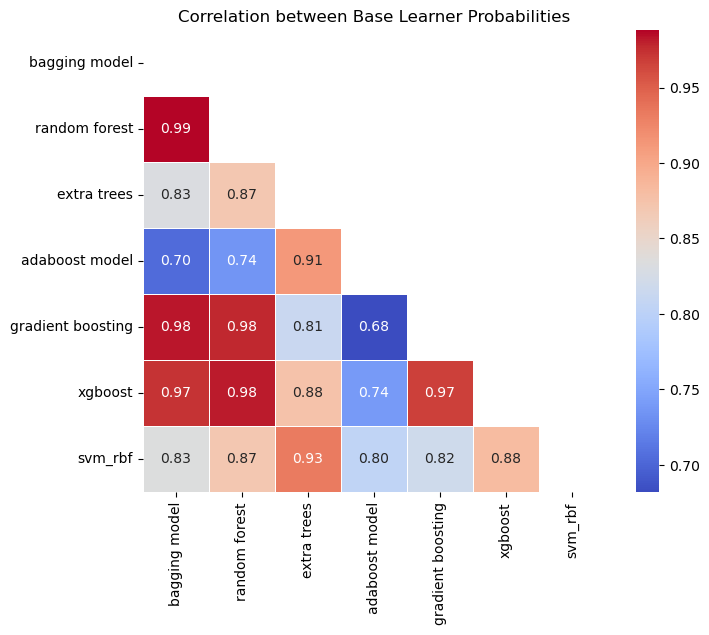

In [41]:
# Correlation between the base learner probabilities (input to the meta learner)

base_probs = pd.DataFrame(
    stacking.transform(x_train),
    columns=base_names
)

plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(base_probs.corr(), dtype=bool))

sns.heatmap(
    base_probs.corr(),
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation between Base Learner Probabilities")
plt.show()

## Meta Learner Coefficients -- Inference



Extra Trees gets the highest weight from the meta learner.

But the coefficients cannot be read directly because of multicollinearity among the base learner probabilities. Bagging and Random Forest are 0.99 correlated, so they are practically the same model. The meta learner has split one weight between the two of them.

In the same way Gradient Boosting is 0.98 correlated with Random Forest and Bagging, so it gets almost zero weight. It is not a bad model, it just doesn't add anything new.

So for the Voting Classifier the top 3 distinct models by coefficient are taken:

1) Extra Trees -- Highest coefficient (1.7566)
2) Random Forest -- Kept instead of Bagging (0.99 correlated) as it has the better test accuracy
3) XGBoost -- Next highest coefficient (0.9153)

# Meta Learner -- Voting Classifier

# Hard Voting

In [42]:
# Hard Voting -- Majority vote of the predicted class

voting_hard = VotingClassifier(
    estimators=[
        ("extra trees", extra_trees_model),
        ("random forest", random_forest_model),
        ("xgboost", xgb_model)
    ],
    voting="hard",            # Majority vote of the predicted class
    n_jobs=-1                 # Use all available CPU cores
)

voting_hard.fit(x_train, y_train)

# Predictions
y_train_pred_vh = voting_hard.predict(x_train)
y_test_pred_vh = voting_hard.predict(x_test)

# Accuracy Scores
train_acc_vh = accuracy_score(y_train, y_train_pred_vh)
test_acc_vh = accuracy_score(y_test, y_test_pred_vh)


print("=" * 60)
print("VOTING CLASSIFIER -- HARD")
print("=" * 60)

print(f"Training Accuracy : {train_acc_vh:.4f}")
print(f"Testing Accuracy  : {test_acc_vh:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_vh))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_vh))

VOTING CLASSIFIER -- HARD
Training Accuracy : 0.9228
Testing Accuracy  : 0.8156

Training Confusion Matrix
[[421  18]
 [ 37 236]]

Testing Confusion Matrix
[[98 12]
 [21 48]]


# Soft Voting

In [43]:
# Soft Voting -- Average of the predicted probabilities

voting_soft = VotingClassifier(
    estimators=[
        ("extra trees", extra_trees_model),
        ("random forest", random_forest_model),
        ("xgboost", xgb_model)
    ],
    voting="soft",            # Average of the predicted probabilities
    n_jobs=-1                 # Use all available CPU cores
)

voting_soft.fit(x_train, y_train)

# Predictions
y_train_pred_vs = voting_soft.predict(x_train)
y_test_pred_vs = voting_soft.predict(x_test)

# Accuracy Scores
train_acc_vs = accuracy_score(y_train, y_train_pred_vs)
test_acc_vs = accuracy_score(y_test, y_test_pred_vs)


print("=" * 60)
print("VOTING CLASSIFIER -- SOFT")
print("=" * 60)

print(f"Training Accuracy : {train_acc_vs:.4f}")
print(f"Testing Accuracy  : {test_acc_vs:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_vs))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_vs))

VOTING CLASSIFIER -- SOFT
Training Accuracy : 0.9242
Testing Accuracy  : 0.7989

Training Confusion Matrix
[[420  19]
 [ 35 238]]

Testing Confusion Matrix
[[96 14]
 [22 47]]


In [44]:
# Compiled Result -- All Models

results_all = {
    "Model": [],
    "Train Accuracy": [],
    "Test Accuracy": [],
    "Accuracy Gap": [],
    "Test Precision": [],
    "Test Recall": [],
    "Test F1": []
}

models_to_compare = [
    ("Bagging",             y_train_pred_bag,   y_test_pred_bag),
    ("Random Forest",       y_train_pred_rf,    y_test_pred_rf),
    ("Extra Trees",         y_train_pred_et,    y_test_pred_et),
    ("AdaBoost",            y_train_pred_ada,   y_test_pred_ada),
    ("Gradient Boosting",   y_train_pred_gb,    y_test_pred_gb),
    ("XGBoost",             y_train_pred_xgb,   y_test_pred_xgb),
    ("Stacking",            y_train_pred_stack, y_test_pred_stack),
    ("Voting (Hard)",       y_train_pred_vh,    y_test_pred_vh),
    ("Voting (Soft)",       y_train_pred_vs,    y_test_pred_vs)
]

for name, y_tr_pred, y_te_pred in models_to_compare:

    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc = accuracy_score(y_test, y_te_pred)

    results_all["Model"].append(name)
    results_all["Train Accuracy"].append(train_acc)
    results_all["Test Accuracy"].append(test_acc)
    results_all["Accuracy Gap"].append(train_acc - test_acc)
    results_all["Test Precision"].append(precision_score(y_test, y_te_pred))
    results_all["Test Recall"].append(recall_score(y_test, y_te_pred))
    results_all["Test F1"].append(f1_score(y_test, y_te_pred))

results_all = pd.DataFrame(results_all)

metric_cols = results_all.columns.drop("Model")
results_all[metric_cols] = (results_all[metric_cols] * 100).round(2)

# Add Decision Tree and SVM results from earlier
final["Accuracy Gap"] = (final["Train Accuracy"] - final["Test Accuracy"]).round(2)

results_all = pd.concat([final[results_all.columns], results_all], ignore_index=True)

# Sort by Test Accuracy and reset the index so rows are numbered in order
results_all = results_all.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

display(results_all)

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Test Precision,Test Recall,Test F1
0,Random Forest,94.24,82.68,11.56,79.69,73.91,76.69
1,Bagging,96.07,81.56,14.50,77.27,73.91,75.56
2,Voting (Hard),92.28,81.56,10.71,80.00,69.57,74.42
3,Extra Trees,82.58,81.01,1.58,77.78,71.01,74.24
4,Gradient Boosting,95.93,81.01,14.92,76.92,72.46,74.63
5,DT gini,98.31,80.45,17.86,73.61,76.81,75.18
6,Stacking,92.42,80.45,11.97,77.42,69.57,73.28
7,SVM linear,77.25,79.89,-2.64,72.00,78.26,75.00
8,SVM rbf,82.72,79.89,2.83,69.88,84.06,76.32
9,XGBoost,91.57,79.89,11.68,77.05,68.12,72.31


# Optimisation -- Hyperparameter Tuning

Models taken for optimisation on the basis of the results above:

1) Random Forest -- Highest test accuracy (82.68%) but a train-test gap of 11.56%
2) Extra Trees -- Highest coefficient in the meta learner (1.7566) with the lowest gap, max_depth=5 might be underfitting it
3) SVM rbf -- Highest test recall (84.06%), C and gamma were never tuned
4) XGBoost -- Overfitting with a gap of 11.68%, its regularisation parameters can be tuned

Gradient Boosting is left out because tuning 1000 trees is very slow. XGBoost already covers the boosting family.

The same Stratified 5-Fold split is used for every search so all the models are compared on the same folds.

In [45]:
# Same folds for every search

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Forest -- Grid Search

In [46]:
model_rf = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

model_rf

Pipeline(steps=[('preprocessor_Imputation_Only',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Embarked', 'Sex'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [47]:
#   RANDOM FOREST GRID SEARCH
rf_param_grid = {
    'classifier__n_estimators': [100, 300],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [4, 6, 8, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

print("=== RUNNING RANDOM FOREST GRIDSEARCHCV ===")
rf_grid = GridSearchCV(
    estimator=model_rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose =1
)
rf_grid.fit(x_train, y_train)

=== RUNNING RANDOM FOREST GRIDSEARCHCV ===
Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor_Imputation_Only',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(handle_unknow...
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [4, 6, 8, 10],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 300]},
             scoring='accuracy', verbose=1)

In [48]:
print(
    "The best parameters are %s with a score of %0.2f"
    % (rf_grid.best_params_, rf_grid.best_score_)
)

print(
    f"Total number of fits: "
    f"{len(rf_grid.cv_results_['mean_test_score']) * cv.get_n_splits()}"
)

The best parameters are {'classifier__criterion': 'entropy', 'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100} with a score of 0.83
Total number of fits: 1440


In [49]:
rf_best = rf_grid.best_estimator_

y_train_pred_rf_tuned = rf_best.predict(x_train)
y_test_pred_rf_tuned = rf_best.predict(x_test)

rf_train_acc = accuracy_score(y_train, y_train_pred_rf_tuned)
rf_test_acc = accuracy_score(y_test, y_test_pred_rf_tuned)


print("=" * 60)
print("RANDOM FOREST -- TUNED")
print("=" * 60)

print(f"Training Accuracy : {rf_train_acc:.4f}")
print(f"Testing Accuracy  : {rf_test_acc:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_rf_tuned))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_rf_tuned))

RANDOM FOREST -- TUNED
Training Accuracy : 0.9101
Testing Accuracy  : 0.7989

Training Confusion Matrix
[[414  25]
 [ 39 234]]

Testing Confusion Matrix
[[95 15]
 [21 48]]


# Extra Trees -- Grid Search

In [50]:
model_et = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ("classifier", ExtraTreesClassifier(random_state=42, n_jobs=-1))
])

model_et

Pipeline(steps=[('preprocessor_Imputation_Only',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Embarked', 'Sex'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 ExtraTreesClassifier(n_jobs=-1, random_state=42))])

In [51]:
#   EXTRA TREES GRID SEARCH
et_param_grid = {
    'classifier__n_estimators': [100, 300],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [4, 5, 6, 8, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None]
}

print("=== RUNNING EXTRA TREES GRIDSEARCHCV ===")
et_grid = GridSearchCV(
    estimator=model_et,
    param_grid=et_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose =1
)
et_grid.fit(x_train, y_train)

=== RUNNING EXTRA TREES GRIDSEARCHCV ===
Fitting 5 folds for each of 540 candidates, totalling 2700 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor_Imputation_Only',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(handle_unknow...
                                       ('classifier',
                                        ExtraTreesClassifier(n_jobs=-1,
                                                             random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [4, 5, 6, 8, 10],
                         'classifier__max_features': ['sqrt', 'log2', None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 300]},
             scoring='accuracy', verbose=1)

In [52]:
print(
    "The best parameters are %s with a score of %0.2f"
    % (et_grid.best_params_, et_grid.best_score_)
)

print(
    f"Total number of fits: "
    f"{len(et_grid.cv_results_['mean_test_score']) * cv.get_n_splits()}"
)

The best parameters are {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300} with a score of 0.82
Total number of fits: 2700


In [53]:
et_best = et_grid.best_estimator_

y_train_pred_et_tuned = et_best.predict(x_train)
y_test_pred_et_tuned = et_best.predict(x_test)

et_train_acc = accuracy_score(y_train, y_train_pred_et_tuned)
et_test_acc = accuracy_score(y_test, y_test_pred_et_tuned)


print("=" * 60)
print("EXTRA TREES -- TUNED")
print("=" * 60)

print(f"Training Accuracy : {et_train_acc:.4f}")
print(f"Testing Accuracy  : {et_test_acc:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_et_tuned))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_et_tuned))

EXTRA TREES -- TUNED
Training Accuracy : 0.8820
Testing Accuracy  : 0.7933

Training Confusion Matrix
[[409  30]
 [ 54 219]]

Testing Confusion Matrix
[[94 16]
 [21 48]]


# SVM rbf -- Grid Search

In [54]:
model_svm = Pipeline([
    ("preprocessor", preprocessor_svm),
    ("smote", SMOTE(random_state=42)),
    ("classifier", SVC(kernel="rbf", random_state=42))
])

model_svm

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch']),
                                                 ('sex',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Sex']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=4))]),
                                                  ['Pclass', 'Embarked'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', SVC(random_state=42))])

In [55]:
#   SVM RBF GRID SEARCH
svm_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],                  # Penalty for misclassification
    'classifier__gamma': ['scale', 0.001, 0.01, 0.1, 1]       # Reach of each training point
}

print("=== RUNNING SVM RBF GRIDSEARCHCV ===")
svm_grid = GridSearchCV(
    estimator=model_svm,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose =1
)
svm_grid.fit(x_train, y_train)

=== RUNNING SVM RBF GRIDSEARCHCV ===
Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare',
                                                                          'SibSp',
                                                                          'Parch']),
                                                                        ('sex',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(s...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='infrequent_if_exist',
                                                                                                        min_frequency=4))]),
                                                                         ['Pclass',
                                                                          'Embarked'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__gamma': ['scale', 0.001, 0.01, 0.1, 1]},
             scoring='accuracy', verbose=1)

In [56]:
print(
    "The best parameters are %s with a score of %0.2f"
    % (svm_grid.best_params_, svm_grid.best_score_)
)

print(
    f"Total number of fits: "
    f"{len(svm_grid.cv_results_['mean_test_score']) * cv.get_n_splits()}"
)

The best parameters are {'classifier__C': 10, 'classifier__gamma': 'scale'} with a score of 0.82
Total number of fits: 125


In [57]:
svm_best = svm_grid.best_estimator_

y_train_pred_svm_tuned = svm_best.predict(x_train)
y_test_pred_svm_tuned = svm_best.predict(x_test)

svm_train_acc = accuracy_score(y_train, y_train_pred_svm_tuned)
svm_test_acc = accuracy_score(y_test, y_test_pred_svm_tuned)


print("=" * 60)
print("SVM RBF -- TUNED")
print("=" * 60)

print(f"Training Accuracy : {svm_train_acc:.4f}")
print(f"Testing Accuracy  : {svm_test_acc:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_svm_tuned))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_svm_tuned))

SVM RBF -- TUNED
Training Accuracy : 0.8483
Testing Accuracy  : 0.7821

Training Confusion Matrix
[[372  67]
 [ 41 232]]

Testing Confusion Matrix
[[87 23]
 [16 53]]


# XGBoost -- Randomized Search

The XGBoost grid is too big for a full grid search, so Randomized Search tries 50 random combinations instead.

In [58]:
model_xgb = Pipeline([
    ("preprocessor_Imputation_Only", preprocessor_Imputation_Only),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

model_xgb

Pipeline(steps=[('preprocessor_Imputation_Only',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Embarked', 'Sex'])])),
                ('smote', SMOTE(ra...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [59]:
#   XGBOOST RANDOMIZED SEARCH
xgb_param_grid = {
    'classifier__n_estimators': [100, 300, 500],            # Number of boosting trees
    'classifier__learning_rate': [0.01, 0.05, 0.1],         # Contribution of each tree
    'classifier__max_depth': [2, 3, 4, 5],                  # Maximum depth of each tree
    'classifier__subsample': [0.7, 0.85, 1.0],              # % of rows used for each tree
    'classifier__colsample_bytree': [0.7, 0.85, 1.0],       # % of features used for each tree
    'classifier__reg_lambda': [1, 5, 10],                   # L2 regularization (Ridge)
    'classifier__gamma': [0, 0.5, 1]                        # Minimum loss reduction required for a split
}

print("=== RUNNING XGBOOST RANDOMIZEDSEARCHCV ===")
xgb_random = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=xgb_param_grid,
    n_iter=50,
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose =1
)
xgb_random.fit(x_train, y_train)

=== RUNNING XGBOOST RANDOMIZEDSEARCHCV ===
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor_Imputation_Only',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['Age']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OrdinalEncoder(handle_...
                   n_iter=50, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.85,
                                                                         1.0],
                                        'classifier__gamma': [0, 0.5, 1],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [2, 3, 4, 5],
                                        'classifier__n_estimators': [100, 300,
                                                                     500],
                                        'classifier__reg_lambda': [1, 5, 10],
                                        'classifier__subsample': [0.7, 0.85,
                                                                  1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [60]:
print(
    "The best parameters are %s with a score of %0.2f"
    % (xgb_random.best_params_, xgb_random.best_score_)
)

print(
    f"Total number of fits: "
    f"{len(xgb_random.cv_results_['mean_test_score']) * cv.get_n_splits()}"
)

The best parameters are {'classifier__subsample': 0.7, 'classifier__reg_lambda': 5, 'classifier__n_estimators': 100, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0, 'classifier__colsample_bytree': 1.0} with a score of 0.82
Total number of fits: 250


In [61]:
xgb_best = xgb_random.best_estimator_

y_train_pred_xgb_tuned = xgb_best.predict(x_train)
y_test_pred_xgb_tuned = xgb_best.predict(x_test)

xgb_train_acc = accuracy_score(y_train, y_train_pred_xgb_tuned)
xgb_test_acc = accuracy_score(y_test, y_test_pred_xgb_tuned)


print("=" * 60)
print("XGBOOST -- TUNED")
print("=" * 60)

print(f"Training Accuracy : {xgb_train_acc:.4f}")
print(f"Testing Accuracy  : {xgb_test_acc:.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_xgb_tuned))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_xgb_tuned))

XGBOOST -- TUNED
Training Accuracy : 0.8399
Testing Accuracy  : 0.7765

Training Confusion Matrix
[[387  52]
 [ 62 211]]

Testing Confusion Matrix
[[93 17]
 [23 46]]


# Optimisation -- Compiled Result

In [62]:
# Compiled Result -- Baseline vs Tuned

# CV Accuracy of the baseline models on the same 5 folds (to compare with the tuned best_score_)
rf_base_cv = cross_val_score(random_forest_model, x_train, y_train, cv=cv, scoring='accuracy').mean()
et_base_cv = cross_val_score(extra_trees_model, x_train, y_train, cv=cv, scoring='accuracy').mean()
svm_base_cv = cross_val_score(svm_rbf, x_train, y_train, cv=cv, scoring='accuracy').mean()
xgb_base_cv = cross_val_score(xgb_model, x_train, y_train, cv=cv, scoring='accuracy').mean()

results_tuned = {
    "Model": [],
    "CV Accuracy": [],
    "Train Accuracy": [],
    "Test Accuracy": [],
    "Accuracy Gap": [],
    "Test Precision": [],
    "Test Recall": [],
    "Test F1": []
}

models_to_compare = [
    ("Random Forest (Baseline)", rf_base_cv,              y_train_pred_rf,         y_test_pred_rf),
    ("Random Forest (Tuned)",    rf_grid.best_score_,     y_train_pred_rf_tuned,   y_test_pred_rf_tuned),
    ("Extra Trees (Baseline)",   et_base_cv,              y_train_pred_et,         y_test_pred_et),
    ("Extra Trees (Tuned)",      et_grid.best_score_,     y_train_pred_et_tuned,   y_test_pred_et_tuned),
    ("SVM rbf (Baseline)",       svm_base_cv,             preds_svm_rbf_train,     preds_svm_rbf_test),
    ("SVM rbf (Tuned)",          svm_grid.best_score_,    y_train_pred_svm_tuned,  y_test_pred_svm_tuned),
    ("XGBoost (Baseline)",       xgb_base_cv,             y_train_pred_xgb,        y_test_pred_xgb),
    ("XGBoost (Tuned)",          xgb_random.best_score_,  y_train_pred_xgb_tuned,  y_test_pred_xgb_tuned)
]

for name, cv_acc, y_tr_pred, y_te_pred in models_to_compare:

    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc = accuracy_score(y_test, y_te_pred)

    results_tuned["Model"].append(name)
    results_tuned["CV Accuracy"].append(cv_acc)
    results_tuned["Train Accuracy"].append(train_acc)
    results_tuned["Test Accuracy"].append(test_acc)
    results_tuned["Accuracy Gap"].append(train_acc - test_acc)
    results_tuned["Test Precision"].append(precision_score(y_test, y_te_pred))
    results_tuned["Test Recall"].append(recall_score(y_test, y_te_pred))
    results_tuned["Test F1"].append(f1_score(y_test, y_te_pred))

results_tuned = pd.DataFrame(results_tuned)

metric_cols = results_tuned.columns.drop("Model")
results_tuned[metric_cols] = (results_tuned[metric_cols] * 100).round(2)

display(results_tuned)

,Model,CV Accuracy,Train Accuracy,Test Accuracy,Accuracy Gap,Test Precision,Test Recall,Test F1
0,Random Forest (Baseline),81.60,94.24,82.68,11.56,79.69,73.91,76.69
1,Random Forest (Tuned),82.73,91.01,79.89,11.12,76.19,69.57,72.73
2,Extra Trees (Baseline),80.06,82.58,81.01,1.58,77.78,71.01,74.24
3,Extra Trees (Tuned),82.02,88.20,79.33,8.87,75.00,69.57,72.18
4,SVM rbf (Baseline),81.46,82.72,79.89,2.84,69.88,84.06,76.32
5,SVM rbf (Tuned),82.03,84.83,78.21,6.62,69.74,76.81,73.10
6,XGBoost (Baseline),81.32,91.57,79.89,11.68,77.05,68.12,72.31
7,XGBoost (Tuned),82.44,83.99,77.65,6.34,73.02,66.67,69.70


# Optimisation for Recall

Here the same 4 models and the same parameter grids are tuned again, but with scoring = 'recall' instead of accuracy.

Recall = out of all the passengers who actually survived, how many the model caught. So the aim here is to reduce the False Negatives (survivors predicted as not survived).

# Random Forest -- Recall

In [63]:
#   RANDOM FOREST GRID SEARCH -- RECALL
print("=== RUNNING RANDOM FOREST GRIDSEARCHCV (RECALL) ===")
rf_grid_recall = GridSearchCV(
    estimator=model_rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose =1
)
rf_grid_recall.fit(x_train, y_train)

=== RUNNING RANDOM FOREST GRIDSEARCHCV (RECALL) ===
Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor_Imputation_Only',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(handle_unknow...
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [4, 6, 8, 10],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 300]},
             scoring='recall', verbose=1)

In [64]:
print(
    "The best parameters are %s with a recall of %0.2f"
    % (rf_grid_recall.best_params_, rf_grid_recall.best_score_)
)

The best parameters are {'classifier__criterion': 'gini', 'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100} with a recall of 0.75


In [65]:
rf_best_recall = rf_grid_recall.best_estimator_

y_train_pred_rf_recall = rf_best_recall.predict(x_train)
y_test_pred_rf_recall = rf_best_recall.predict(x_test)


print("=" * 60)
print("RANDOM FOREST -- TUNED FOR RECALL")
print("=" * 60)

print(f"Training Accuracy : {accuracy_score(y_train, y_train_pred_rf_recall):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test, y_test_pred_rf_recall):.4f}")
print(f"Training Recall   : {recall_score(y_train, y_train_pred_rf_recall):.4f}")
print(f"Testing Recall    : {recall_score(y_test, y_test_pred_rf_recall):.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_rf_recall))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_rf_recall))

RANDOM FOREST -- TUNED FOR RECALL
Training Accuracy : 0.8343
Testing Accuracy  : 0.7877
Training Recall   : 0.7692
Testing Recall    : 0.6957

Training Confusion Matrix
[[384  55]
 [ 63 210]]

Testing Confusion Matrix
[[93 17]
 [21 48]]


# Extra Trees -- Recall

In [66]:
#   EXTRA TREES GRID SEARCH -- RECALL
print("=== RUNNING EXTRA TREES GRIDSEARCHCV (RECALL) ===")
et_grid_recall = GridSearchCV(
    estimator=model_et,
    param_grid=et_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose =1
)
et_grid_recall.fit(x_train, y_train)

=== RUNNING EXTRA TREES GRIDSEARCHCV (RECALL) ===
Fitting 5 folds for each of 540 candidates, totalling 2700 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor_Imputation_Only',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         ['Age']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(handle_unknow...
                                       ('classifier',
                                        ExtraTreesClassifier(n_jobs=-1,
                                                             random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [4, 5, 6, 8, 10],
                         'classifier__max_features': ['sqrt', 'log2', None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 300]},
             scoring='recall', verbose=1)

In [67]:
print(
    "The best parameters are %s with a recall of %0.2f"
    % (et_grid_recall.best_params_, et_grid_recall.best_score_)
)

The best parameters are {'classifier__criterion': 'gini', 'classifier__max_depth': 6, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100} with a recall of 0.74


In [68]:
et_best_recall = et_grid_recall.best_estimator_

y_train_pred_et_recall = et_best_recall.predict(x_train)
y_test_pred_et_recall = et_best_recall.predict(x_test)


print("=" * 60)
print("EXTRA TREES -- TUNED FOR RECALL")
print("=" * 60)

print(f"Training Accuracy : {accuracy_score(y_train, y_train_pred_et_recall):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test, y_test_pred_et_recall):.4f}")
print(f"Training Recall   : {recall_score(y_train, y_train_pred_et_recall):.4f}")
print(f"Testing Recall    : {recall_score(y_test, y_test_pred_et_recall):.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_et_recall))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_et_recall))

EXTRA TREES -- TUNED FOR RECALL
Training Accuracy : 0.8272
Testing Accuracy  : 0.7933
Training Recall   : 0.7509
Testing Recall    : 0.7246

Training Confusion Matrix
[[384  55]
 [ 68 205]]

Testing Confusion Matrix
[[92 18]
 [19 50]]


# SVM rbf -- Recall

In [69]:
#   SVM RBF GRID SEARCH -- RECALL
print("=== RUNNING SVM RBF GRIDSEARCHCV (RECALL) ===")
svm_grid_recall = GridSearchCV(
    estimator=model_svm,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose =1
)
svm_grid_recall.fit(x_train, y_train)

=== RUNNING SVM RBF GRIDSEARCHCV (RECALL) ===
Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare',
                                                                          'SibSp',
                                                                          'Parch']),
                                                                        ('sex',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(s...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='infrequent_if_exist',
                                                                                                        min_frequency=4))]),
                                                                         ['Pclass',
                                                                          'Embarked'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__gamma': ['scale', 0.001, 0.01, 0.1, 1]},
             scoring='recall', verbose=1)

In [70]:
print(
    "The best parameters are %s with a recall of %0.2f"
    % (svm_grid_recall.best_params_, svm_grid_recall.best_score_)
)

The best parameters are {'classifier__C': 0.01, 'classifier__gamma': 1} with a recall of 0.93


In [71]:
svm_best_recall = svm_grid_recall.best_estimator_

y_train_pred_svm_recall = svm_best_recall.predict(x_train)
y_test_pred_svm_recall = svm_best_recall.predict(x_test)


print("=" * 60)
print("SVM RBF -- TUNED FOR RECALL")
print("=" * 60)

print(f"Training Accuracy : {accuracy_score(y_train, y_train_pred_svm_recall):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test, y_test_pred_svm_recall):.4f}")
print(f"Training Recall   : {recall_score(y_train, y_train_pred_svm_recall):.4f}")
print(f"Testing Recall    : {recall_score(y_test, y_test_pred_svm_recall):.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_svm_recall))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_svm_recall))

SVM RBF -- TUNED FOR RECALL
Training Accuracy : 0.5941
Testing Accuracy  : 0.5754
Training Recall   : 0.9304
Testing Recall    : 0.8986

Training Confusion Matrix
[[169 270]
 [ 19 254]]

Testing Confusion Matrix
[[41 69]
 [ 7 62]]


# XGBoost -- Recall

In [72]:
#   XGBOOST RANDOMIZED SEARCH -- RECALL
print("=== RUNNING XGBOOST RANDOMIZEDSEARCHCV (RECALL) ===")
xgb_grid_recall = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=xgb_param_grid,
    n_iter=50,
    cv=cv,
    scoring='recall',
    random_state=42,
    n_jobs=-1,
    verbose =1
)
xgb_grid_recall.fit(x_train, y_train)

=== RUNNING XGBOOST RANDOMIZEDSEARCHCV (RECALL) ===
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor_Imputation_Only',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['Age']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OrdinalEncoder(handle_...
                   n_iter=50, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.85,
                                                                         1.0],
                                        'classifier__gamma': [0, 0.5, 1],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [2, 3, 4, 5],
                                        'classifier__n_estimators': [100, 300,
                                                                     500],
                                        'classifier__reg_lambda': [1, 5, 10],
                                        'classifier__subsample': [0.7, 0.85,
                                                                  1.0]},
                   random_state=42, scoring='recall', verbose=1)

In [73]:
print(
    "The best parameters are %s with a recall of %0.2f"
    % (xgb_grid_recall.best_params_, xgb_grid_recall.best_score_)
)

The best parameters are {'classifier__subsample': 0.7, 'classifier__reg_lambda': 1, 'classifier__n_estimators': 300, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.85} with a recall of 0.74


In [74]:
xgb_best_recall = xgb_grid_recall.best_estimator_

y_train_pred_xgb_recall = xgb_best_recall.predict(x_train)
y_test_pred_xgb_recall = xgb_best_recall.predict(x_test)


print("=" * 60)
print("XGBOOST -- TUNED FOR RECALL")
print("=" * 60)

print(f"Training Accuracy : {accuracy_score(y_train, y_train_pred_xgb_recall):.4f}")
print(f"Testing Accuracy  : {accuracy_score(y_test, y_test_pred_xgb_recall):.4f}")
print(f"Training Recall   : {recall_score(y_train, y_train_pred_xgb_recall):.4f}")
print(f"Testing Recall    : {recall_score(y_test, y_test_pred_xgb_recall):.4f}")

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred_xgb_recall))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred_xgb_recall))

XGBOOST -- TUNED FOR RECALL
Training Accuracy : 0.9565
Testing Accuracy  : 0.7933
Training Recall   : 0.9267
Testing Recall    : 0.7246

Training Confusion Matrix
[[428  11]
 [ 20 253]]

Testing Confusion Matrix
[[92 18]
 [19 50]]


# Optimisation for Recall -- Compiled Result

In [75]:
# Compiled Result -- Baseline vs Tuned (Accuracy) vs Tuned (Recall)

results_recall = {
    "Model": [],
    "Train Accuracy": [],
    "Test Accuracy": [],
    "Accuracy Gap": [],
    "Test Precision": [],
    "Test Recall": [],
    "Test F1": []
}

models_to_compare = [
    ("Random Forest (Baseline)",  y_train_pred_rf,          y_test_pred_rf),
    ("Random Forest (Accuracy)",  y_train_pred_rf_tuned,    y_test_pred_rf_tuned),
    ("Random Forest (Recall)",    y_train_pred_rf_recall,   y_test_pred_rf_recall),
    ("Extra Trees (Baseline)",    y_train_pred_et,          y_test_pred_et),
    ("Extra Trees (Accuracy)",    y_train_pred_et_tuned,    y_test_pred_et_tuned),
    ("Extra Trees (Recall)",      y_train_pred_et_recall,   y_test_pred_et_recall),
    ("SVM rbf (Baseline)",        preds_svm_rbf_train,      preds_svm_rbf_test),
    ("SVM rbf (Accuracy)",        y_train_pred_svm_tuned,   y_test_pred_svm_tuned),
    ("SVM rbf (Recall)",          y_train_pred_svm_recall,  y_test_pred_svm_recall),
    ("XGBoost (Baseline)",        y_train_pred_xgb,         y_test_pred_xgb),
    ("XGBoost (Accuracy)",        y_train_pred_xgb_tuned,   y_test_pred_xgb_tuned),
    ("XGBoost (Recall)",          y_train_pred_xgb_recall,  y_test_pred_xgb_recall)
]

for name, y_tr_pred, y_te_pred in models_to_compare:

    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc = accuracy_score(y_test, y_te_pred)

    results_recall["Model"].append(name)
    results_recall["Train Accuracy"].append(train_acc)
    results_recall["Test Accuracy"].append(test_acc)
    results_recall["Accuracy Gap"].append(train_acc - test_acc)
    results_recall["Test Precision"].append(precision_score(y_test, y_te_pred))
    results_recall["Test Recall"].append(recall_score(y_test, y_te_pred))
    results_recall["Test F1"].append(f1_score(y_test, y_te_pred))

results_recall = pd.DataFrame(results_recall)

metric_cols = results_recall.columns.drop("Model")
results_recall[metric_cols] = (results_recall[metric_cols] * 100).round(2)

display(results_recall)

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Test Precision,Test Recall,Test F1
0,Random Forest (Baseline),94.24,82.68,11.56,79.69,73.91,76.69
1,Random Forest (Accuracy),91.01,79.89,11.12,76.19,69.57,72.73
2,Random Forest (Recall),83.43,78.77,4.66,73.85,69.57,71.64
3,Extra Trees (Baseline),82.58,81.01,1.58,77.78,71.01,74.24
4,Extra Trees (Accuracy),88.20,79.33,8.87,75.00,69.57,72.18
5,Extra Trees (Recall),82.72,79.33,3.40,73.53,72.46,72.99
6,SVM rbf (Baseline),82.72,79.89,2.84,69.88,84.06,76.32
7,SVM rbf (Accuracy),84.83,78.21,6.62,69.74,76.81,73.10
8,SVM rbf (Recall),59.41,57.54,1.87,47.33,89.86,62.00
9,XGBoost (Baseline),91.57,79.89,11.68,77.05,68.12,72.31


Since among all the models it is Random forest baseline model has performed really good .. Optmisation might wouldn't have worked because of smaller sample of tuning parameters.